In [3]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train (1).csv


In [4]:
import pandas as pd
train = pd.read_csv('train.csv')
print("Training Set:"% train.columns, train.shape, len(train))
test = pd.read_csv('test.csv')
print("Test Set:"% test.columns, test.shape, len(test))


Training Set: (31962, 3) 31962
Test Set: (17197, 2) 17197


In [6]:
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

def removestopwords(text):

  removestopwords = [word for word in text.split() if word not in stop_words]
  return ' '.join(removestopwords)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [8]:
train

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."


In [11]:

import re
def  clean_text(df, text_field):
    df[text_field] = df[text_field].str.lower()
    df[text_field] = df[text_field].apply(lambda elem: re.sub(r"(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)|^rt|http.+?", "", elem))
    return df
test_clean = clean_text(test, "tweet")
train_clean = clean_text(train, "tweet")

In [12]:
from sklearn.utils import resample
train_majority = train_clean[train_clean.label==0]
train_minority = train_clean[train_clean.label==1]
train_minority_upsampled = resample(train_minority,
                                 replace=True,
                                 n_samples=len(train_majority),
                                 random_state=123)
train_upsampled = pd.concat([train_minority_upsampled, train_majority])
train_upsampled['label'].value_counts()

label
1    29720
0    29720
Name: count, dtype: int64

In [13]:
from sklearn.utils import resample
train_majority = train_clean[train_clean.label==0]
train_minority = train_clean[train_clean.label==1]
train_minority_upsampled = resample(train_minority,
                                 replace=True,
                                 n_samples=len(train_majority),
                                 random_state=123)
train_upsampled = pd.concat([train_minority_upsampled, train_majority])
train_upsampled['label'].value_counts()

label
1    29720
0    29720
Name: count, dtype: int64

In [14]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.linear_model import SGDClassifier
pipeline_sgd = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf',  TfidfTransformer()),
    ('nb', SGDClassifier()),])

In [16]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train_upsampled['tweet'],
                                                    train_upsampled['label'],random_state = 0)

In [17]:
model = pipeline_sgd.fit(X_train, y_train)
y_predict = model.predict(X_test)
from sklearn.metrics import f1_score
f1_score(y_test, y_predict)

0.969272812104246

In [18]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier,
    SGDClassifier,
    PassiveAggressiveClassifier,
    Perceptron,
)
from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.neighbors import (
    KNeighborsClassifier,
    RadiusNeighborsClassifier,
    NearestCentroid,
)
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import *
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from tabulate import tabulate  # Import the tabulate library
from sklearn.neural_network import MLPClassifier


In [22]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from tqdm import tqdm
import warnings
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, LSTM, GRU, Embedding, SimpleRNN, Dropout


# Ignore all warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import *

def evaluate_model(model, x_train, y_train, x_test, y_test):
    # Preprocess 'previous_year_rating' column


    pipe = Pipeline([
         ('vect', CountVectorizer()),
    ('tfidf',  TfidfTransformer()),
        ('model', model),
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # Use appropriate classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred,  average="macro")
    f1 = f1_score(y_test, y_pred,  average="macro")

    # Calculate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    return accuracy, precision, recall, f1, cm


# Initialize different classification models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest Classifier': RandomForestClassifier(),
    'Gradient Boosting Classifier': GradientBoostingClassifier(),
    'AdaBoost Classifier': AdaBoostClassifier(),
    'Bagging Classifier': BaggingClassifier(),
    'Extra Trees Classifier': ExtraTreesClassifier(),
    'Support Vector Classifier': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree Classifier': DecisionTreeClassifier(),

}
# Create a list to store the results
results = []

# Evaluate and print classification metrics for different models
for model_name, model in tqdm(models.items()):
    accuracy, precision, recall, f1, cm = evaluate_model(model, X_train, y_train, X_test, y_test)
    results.append([model_name, accuracy, precision, recall, f1, cm])

# Print the results in a tabular form
headers = ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "Confusion Matrix"]
print(tabulate(results, headers, tablefmt="grid"))

max_accuracy_index = np.argmax([result[1] for result in results])
best_model_name = results[max_accuracy_index][0]
print(f"\nThe model with the highest accuracy is: {best_model_name} (Accuracy: {results[max_accuracy_index][1]:.4f})")

100%|██████████| 9/9 [13:44<00:00, 91.62s/it] 

+------------------------------+------------+-------------+----------+------------+--------------------+
| Model                        |   Accuracy |   Precision |   Recall |   F1 Score | Confusion Matrix   |
+==============================+============+=============+==========+============+====================+
| Logistic Regression          |   0.973015 |    0.973589 | 0.97317  |   0.973011 | [[7145  345]       |
|                              |            |             |          |            |  [  56 7314]]      |
+------------------------------+------------+-------------+----------+------------+--------------------+
| Random Forest Classifier     |   0.998587 |    0.998579 | 0.998598 |   0.998587 | [[7469   21]       |
|                              |            |             |          |            |  [   0 7370]]      |
+------------------------------+------------+-------------+----------+------------+--------------------+
| Gradient Boosting Classifier |   0.807537 |    0.8113

In [23]:

K = train_upsampled['label'].max() + 1
K

2

In [26]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Convert sentences to sequences

MAX_VOCAB_SIZE = 2000
tokenizer = Tokenizer(num_words =MAX_VOCAB_SIZE )
tokenizer.fit_on_texts(train_upsampled['tweet'])
sequences_train = tokenizer.texts_to_sequences(train_upsampled['tweet'])
sequences_test = tokenizer.texts_to_sequences(test['tweet'])

In [27]:

# get word -> integer mapping

word2idx = tokenizer.word_index
V = len(word2idx)
print("Found %s unique tokens."% V)

Found 41445 unique tokens.


In [29]:
# pad sequences so that we gwt a N*T matrix
from tensorflow.keras.preprocessing.sequence import pad_sequences

data_train = pad_sequences(sequences_train)
print('Shape of data train tensor:', data_train.shape)

Shape of data train tensor: (59440, 31)


In [30]:
T = data_train.shape[1]


In [31]:
T

31

In [32]:

data_test = pad_sequences(sequences_test, maxlen =T)
print('shape of data test tensor:', data_test.shape)

shape of data test tensor: (17197, 31)


In [141]:
from keras.layers import Input, Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense
from keras.models import Model

# Parameters
D = 50  # Embedding dimension

# Input layer
i = Input(shape=(T,))

# Embedding layer
x = Embedding(V + 1, D)(i)  # V+1 because index 0 is reserved for padding

# Convolutional layers
x = Conv1D(32, 3, activation='relu')(x)
x = MaxPooling1D(2)(x)  # Adjust pool_size to 2
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(2)(x)  # Adjust pool_size to 2
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)

# Dense output layer
x = Dense(K, activation='softmax')(x)  # Replace x with your last layer output

# Create model
model = Model(i, x)


In [142]:
model.summary()

Model: "model_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_11 (InputLayer)       [(None, 39)]              0         
                                                                 
 embedding_10 (Embedding)    (None, 39, 50)            1978450   
                                                                 
 conv1d_22 (Conv1D)          (None, 37, 32)            4832      
                                                                 
 max_pooling1d_13 (MaxPooli  (None, 18, 32)            0         
 ng1D)                                                           
                                                                 
 conv1d_23 (Conv1D)          (None, 16, 64)            6208      
                                                                 
 max_pooling1d_14 (MaxPooli  (None, 8, 64)             0         
 ng1D)                                                     

In [143]:
from keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

model.compile(
    loss = SparseCategoricalCrossentropy(from_logits = True),
    optimizer = Adam(learning_rate = 1e-3),
    metrics = ['accuracy']
)


In [144]:

from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [ ]:

print('Training Model')

r = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]  # Include early stopping callback
)

In [70]:
X_train

23346    how the supremecou has made it impossible to c...
6948        ineedtoconsult  bro t i have lot of unanswe...
20511    model   i love u take with u all the time in u...
863      trumpusa when they call us   homophobic misogy...
27142                   happy end manga anime skrin  end  
                               ...                        
17378    a true junglist massiverip legend tenorfly dru...
24406       has to get permission from her handlers bef...
13864                                       damn orlando  
14885      good vibes  italy travel trip   me bike fit ...
26602     have you joined the pizza pay were talking pi...
Name: tweet, Length: 44580, dtype: object

In [71]:
data = pd.read_csv('/content/train.csv')

In [72]:
data

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."


In [73]:
data['label'] = data['label'].astype('category').cat.codes


In [75]:
# Number of classes

K = data['label'].max() + 1
K

2

In [78]:
df_train, df_test = train_test_split(data, test_size = 0.2)


In [80]:
class_names = df_train.label.unique()


In [81]:
class_names

array([0, 1], dtype=int8)

In [82]:
# Convert sentences to sequences

MAX_VOCAB_SIZE = 2000
tokenizer = Tokenizer(num_words =MAX_VOCAB_SIZE )
tokenizer.fit_on_texts(df_train['tweet'])
sequences_train = tokenizer.texts_to_sequences(df_train['tweet'])
sequences_test = tokenizer.texts_to_sequences(df_test['tweet'])

In [83]:
# get word -> integer mapping

word2idx = tokenizer.word_index
V = len(word2idx)
print("Found %s unique tokens."% V)

Found 39568 unique tokens.


In [84]:

# pad sequences so that we gwt a N*T matrix

data_train = pad_sequences(sequences_train)
print('Shape of data train tensor:', data_train.shape)

Shape of data train tensor: (25569, 39)


In [85]:

# get sequences length

T = data_train.shape[1]
T

39

In [86]:

data_test = pad_sequences(sequences_test, maxlen =T)
print('shape of data test tensor:', data_test.shape)


shape of data test tensor: (6393, 39)


In [152]:
from keras.layers import Input, Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense
from keras.models import Model

# Parameters
D = 50  # Embedding dimension

# Input layer
i = Input(shape=(T,))

# Embedding layer
x = Embedding(V + 1, D)(i)  # V+1 because index 0 is reserved for padding

# Convolutional layers
x = Conv1D(32, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
# x= Dropout(0.2)(x)
# x = Conv1D(64, 3, activation='relu')(x)
# x = MaxPooling1D(3)(x)
# x= Dropout(0.2)(x)

x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x= Dropout(0.2)(x)

# Dense output layer
x = Dense(K, activation='softmax')(x)  # Replace x with your last layer output

# Create model
model = Model(i, x)





In [153]:
model.summary()

Model: "model_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_13 (InputLayer)       [(None, 39)]              0         
                                                                 
 embedding_12 (Embedding)    (None, 39, 50)            1978450   
                                                                 
 conv1d_28 (Conv1D)          (None, 37, 32)            4832      
                                                                 
 max_pooling1d_17 (MaxPooli  (None, 12, 32)            0         
 ng1D)                                                           
                                                                 
 conv1d_29 (Conv1D)          (None, 10, 128)           12416     
                                                                 
 global_max_pooling1d_9 (Gl  (None, 128)               0         
 obalMaxPooling1D)                                        

In [154]:
from keras.optimizers import Adam


model.compile(
    loss = SparseCategoricalCrossentropy(from_logits = True),
    optimizer = Adam(),
    metrics = ['accuracy']
)

In [155]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)



In [156]:
print('Training Model......')

r = model.fit(
    data_train,
    df_train['label'],
    epochs=100,
    validation_data=(data_test, df_test['label']),
    callbacks=[early_stopping]  # Include early stopping callback
)

Training Model......
Epoch 1/100
800/800 [==============================] - 26s 31ms/step - loss: 0.2071 - accuracy: 0.9326 - val_loss: 0.1617 - val_accuracy: 0.9445
Epoch 2/100
800/800 [==============================] - 21s 26ms/step - loss: 0.1251 - accuracy: 0.9540 - val_loss: 0.1587 - val_accuracy: 0.9495
Epoch 3/100
800/800 [==============================] - 22s 27ms/step - loss: 0.0945 - accuracy: 0.9661 - val_loss: 0.1791 - val_accuracy: 0.9515
Epoch 4/100
800/800 [==============================] - 21s 26ms/step - loss: 0.0691 - accuracy: 0.9761 - val_loss: 0.2061 - val_accuracy: 0.9435
Epoch 5/100
800/800 [==============================] - 21s 27ms/step - loss: 0.0504 - accuracy: 0.9833 - val_loss: 0.2351 - val_accuracy: 0.9459
Epoch 6/100
800/800 [==============================] - 21s 26ms/step - loss: 0.0321 - accuracy: 0.9900 - val_loss: 0.2970 - val_accuracy: 0.9487
Epoch 7/100
800/800 [==============================] - 21s 27ms/step - loss: 0.0223 - accuracy: 0.9931 - val_

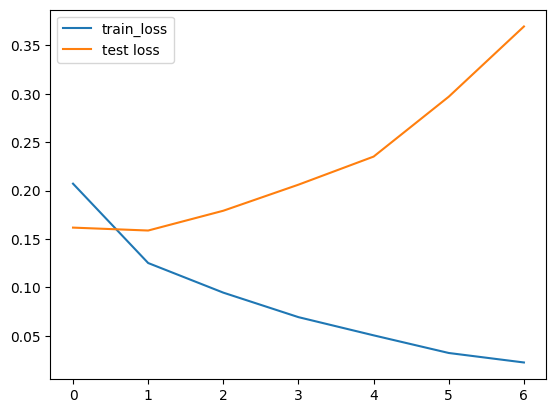

In [157]:
# Plot loss per iteration
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'test loss')
plt.legend()

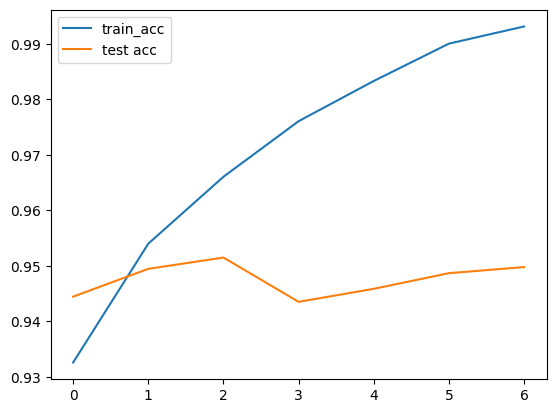

In [158]:

# Plot acc per iteration
plt.plot(r.history['accuracy'], label = 'train_acc')
plt.plot(r.history['val_accuracy'], label = 'test acc')
plt.legend()

In [159]:

train_loss, train_accuracy = model.evaluate(data_train, df_train['label'])
test_loss, test_accuracy = model.evaluate(data_test, df_test['label'])

print(f"Train Accuracy: {train_accuracy:.4f}")


print(f"Test Accuracy: {test_accuracy:.4f}")

200/200 [==============================] - 1s 4ms/step - loss: 0.1587 - accuracy: 0.9495
Train Accuracy: 0.9687
Test Accuracy: 0.9495


In [160]:


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


y_train_pred = model.predict(data_train)
y_test_pred = model.predict(data_test)

200/200 [==============================] - 0s 2ms/step


In [161]:
# Accuracy
train_accuracy = accuracy_score(df_train['label'], y_train_pred.argmax(axis=1))
test_accuracy = accuracy_score(df_test['label'], y_test_pred.argmax(axis=1))

# Precision, Recall, F1-score
train_precision = precision_score(df_train['label'], y_train_pred.argmax(axis=1), average='macro')
test_precision = precision_score(df_test['label'], y_test_pred.argmax(axis=1), average='macro')

train_recall = recall_score(df_train['label'], y_train_pred.argmax(axis=1), average='macro')
test_recall = recall_score(df_test['label'], y_test_pred.argmax(axis=1), average='macro')

train_f1 = f1_score(df_train['label'], y_train_pred.argmax(axis=1), average='macro')
test_f1 = f1_score(df_test['label'], y_test_pred.argmax(axis=1), average='macro')

# train_probs = y_train_pred  # Shape should be (num_samples, num_classes)
# test_probs = y_test_pred    # Shape should be (num_samples, num_classes)

# # AUC-ROC Score
# train_auc = roc_auc_score(df_train['label'], train_probs, multi_class='ovr', average='macro')
# test_auc = roc_auc_score(df_test['label'], test_probs, multi_class='ovr', average='macro')

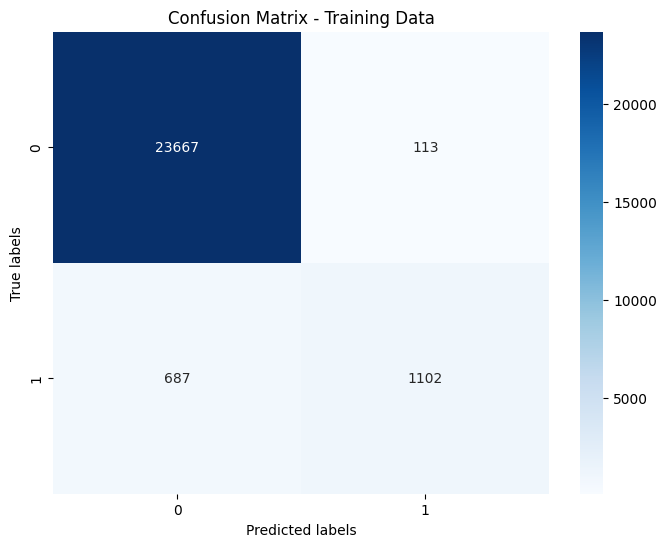

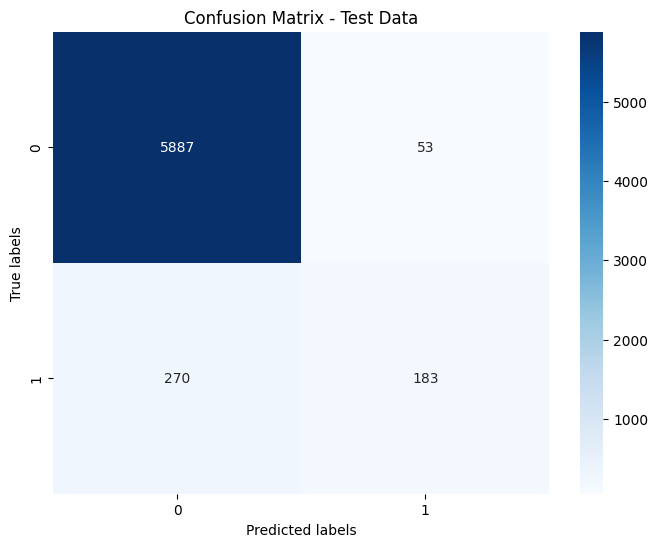

In [162]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.show()

# Define class labels
class_labels = class_names

# Plot confusion matrix for training data
plot_confusion_matrix(df_train['label'], y_train_pred.argmax(axis=1), labels=class_labels, title='Confusion Matrix - Training Data')

# Plot confusion matrix for test data
plot_confusion_matrix(df_test['label'], y_test_pred.argmax(axis=1), labels=class_labels, title='Confusion Matrix - Test Data')


In [163]:
from sklearn.metrics import classification_report

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
# Calculate classification report
train_report = classification_report(df_train['label'], y_train_pred.argmax(axis=1))
test_report = classification_report(df_test['label'], y_test_pred.argmax(axis=1))

# Print evaluation metrics
print("Evaluation Metrics - Training Data:")
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Train Precision: {train_precision:.4f}")
print(f"Train Recall: {train_recall:.4f}")
print(f"Train F1-score: {train_f1:.4f}")
# print(f"Train AUC-ROC Score: {train_auc:.4f}")

print("\nEvaluation Metrics - Test Data:")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-score: {test_f1:.4f}")
# print(f"Test AUC-ROC Score: {test_auc:.4f}")

# Print classification report
print("\nClassification Report - Training Data:")
print(train_report)

print("\nClassification Report - Test Data:")
print(test_report)

Evaluation Metrics - Training Data:
Train Accuracy: 0.9687
Train Precision: 0.9394
Train Recall: 0.8056
Train F1-score: 0.8585

Evaluation Metrics - Test Data:
Test Accuracy: 0.9495
Test Precision: 0.8658
Test Recall: 0.6975
Test F1-score: 0.7523

Classification Report - Training Data:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     23780
           1       0.91      0.62      0.73      1789

    accuracy                           0.97     25569
   macro avg       0.94      0.81      0.86     25569
weighted avg       0.97      0.97      0.97     25569


Classification Report - Test Data:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      5940
           1       0.78      0.40      0.53       453

    accuracy                           0.95      6393
   macro avg       0.87      0.70      0.75      6393
weighted avg       0.94      0.95      0.94      6393

